# Zen EliteStride Maison - Sales Analysis 

Stage 4 of a five-part pipeline: **Excel → Power BI → SQL → Python → Machine Learning**.

This notebook loads the same raw dataset used in the earlier stages, cleans it,
recomputes the same KPIs, answers all 7 business questions plus a management
recommendation, and produces charts entirely in Python.

**Business Questions:**
1. How is the business performing overall?
2. How have revenue and profit changed over time?
3. Which products are driving sales?
4. Which products are driving profitability?
5. Which categories and brands perform best?
6. Which countries contribute the most to the business?
7. What purchasing patterns can we identify from payment method and product preferences?
8. What actions should management take based on the findings?



## Step 1: Import libraries

- `pandas` - loading and manipulating the tabular data
- `matplotlib` / `seaborn` - charts


In [25]:
# Import pandas for tabular data manipulation and analysis.
import pandas as pd

# Import Matplotlib and Seaborn for data visualization.
import matplotlib.pyplot as plt
import seaborn as sns

# Apply a consistent visual style to all Seaborn charts.
sns.set_theme(style="whitegrid")

# Display numeric values with two decimal places and thousands separators.
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Define the Excel workbook used as the analysis source.
SOURCE_FILE = "Zen EliteStride Maison_Python.xlsx"


## Step 2: Load the data

The Excel file has two sheets I need: `Shoe Sales` (the transactions) and
`Price` (the per-product price/cost lookup).


In [26]:
# Load transaction records and the product price/cost lookup table.
sales = pd.read_excel(SOURCE_FILE, sheet_name="Shoe Sales")
price = pd.read_excel(SOURCE_FILE, sheet_name="Price")

# Remove empty helper columns that may have been introduced by the Excel export.
sales = sales.loc[:, ~sales.columns.str.contains("^Unnamed")]

# Preview the raw sales data.
sales.head()


,Date,Product,Category,Color,Brand,Country,Quantity,Payment Type
0,2026-05-19,monk straps,Formal,Red,Nike,Uganda,7,Bank Transfer
1,2026-06-26,loafers,Formal,Black,nike,Uganda,1,Card
2,2026-05-30,Derby,FORMAL,Green,clarks,Nigeria,7,Bank Transfer
3,2026-07-11,boots,UTILITY,Black,nike,Canada,6,Bank Transfer
4,2026-04-18,BOOTS,casual,Red,CLARKS,UK,6,Bank Transfer


## Step 3: Clean the data

The raw `Shoe Sales`sheet has inconsistent capitalization and stray
whitespace in its text columns-e.g. `'monk straps '`, `'MONK STRAPS'`,
and `'Monk Straps'`all refer to the same product. If I don't standardize
these before joining to the `Price` table, some rows will silently fail to
match and understate revenue/profit (this is the same bug we found and
fixed in the Power BI and SQL stages of this project).

`.str.strip()` removes leading/trailing spaces. `.str.title()`standardizes
capitalization.


In [27]:
# List the sales columns that require text standardization.
text_cols_sales = ["Product", "Category", "Color", "Brand", "Country", "Payment Type"]

# Remove extra spaces and standardize capitalization for consistent analysis.
for col in text_cols_sales:
    sales[col] = sales[col].astype(str).str.strip().str.title()

# Apply the same product-name standardization to the price lookup table.
price["Product"] = price["Product"].astype(str).str.strip().str.title()

# Convert dates and quantities to appropriate analytical data types.
sales["Date"] = pd.to_datetime(sales["Date"])
sales["Quantity"] = pd.to_numeric(sales["Quantity"], errors="coerce")

# Identify products that would fail to match during the price lookup.
unmatched = sales.loc[~sales["Product"].isin(price["Product"]), "Product"].unique()
print("Unmatched products after cleaning:", unmatched if len(unmatched) else "none (all matched)")


Unmatched products after cleaning: none (all matched)


## Step 4: Merge sales with price and derive Revenue / Cost / Profit

`Revenue`, `Cost_Total`, and `Profit` are not in the raw data - I calculate
them here from `Quantity`, `Price`, and `Cost` once the two tables are joined
on the cleaned `Product` column.


In [28]:
# Combine each sales transaction with its corresponding product price and cost.
df = sales.merge(price, on="Product", how="left")

# Calculate total revenue generated by each transaction.
df["Revenue"] = df["Quantity"] * df["Price"]

# Calculate the total cost of the units sold in each transaction.
df["Cost_Total"] = df["Quantity"] * df["Cost"]

# Calculate profit by subtracting total cost from revenue.
df["Profit"] = df["Revenue"] - df["Cost_Total"]

# Preview the first five rows of the enriched dataset.
df.head()


,Date,Product,Category,Color,Brand,Country,Quantity,Payment Type,Price,Cost,Revenue,Cost_Total,Profit
0,2026-05-19,Monk Straps,Formal,Red,Nike,Uganda,7,Bank Transfer,89,47,623,329,294
1,2026-06-26,Loafers,Formal,Black,Nike,Uganda,1,Card,54,28,54,28,26
2,2026-05-30,Derby,Formal,Green,Clarks,Nigeria,7,Bank Transfer,32,14,224,98,126
3,2026-07-11,Boots,Utility,Black,Nike,Canada,6,Bank Transfer,76,39,456,234,222
4,2026-04-18,Boots,Casual,Red,Clarks,Uk,6,Bank Transfer,76,39,456,234,222


# Business Questions

## Q1: How is the business performing overall?

The headline KPIs: total revenue, total cost, total profit, overall profit
margin, average order value, and total units sold.


In [32]:
# Calculate the primary business performance measures.
total_revenue = df["Revenue"].sum()
total_cost = df["Cost_Total"].sum()
total_profit = df["Profit"].sum()

# Express profit as a percentage of total revenue.
profit_margin_pct = round(total_profit / total_revenue * 100, 2)

# Calculate the average revenue per transaction and total units sold.
avg_order_value = round(total_revenue / len(df), 2)
total_quantity = df["Quantity"].sum()

# Print the headline KPIs for management review.
print(f"Total Revenue:    {total_revenue:,.2f}")
print(f"Total Cost:       {total_cost:,.2f}")
print(f"Total Profit:     {total_profit:,.2f}")
print(f"Profit Margin %:  {profit_margin_pct}%")
print(f"Avg Order Value:  {avg_order_value}")
print(f"Total Quantity:   {total_quantity}")
print(f"Total Transactions: {len(df)}")


Total Revenue:    355,048.00
Total Cost:       192,713.00
Total Profit:     162,335.00
Profit Margin %:  45.72%
Avg Order Value:  710.1
Total Quantity:   4012
Total Transactions: 500


## Q2: How have revenue and profit changed over time?

Resampling by month (`'ME'` = month end) turns 500 individual transactions
into a monthly trend. `pct_change()` gives month-over-month growth.


In [34]:
# Aggregate revenue and profit by calendar month.
monthly = (
    df.set_index("Date")
    .resample("ME")[["Revenue", "Profit"]]
    .sum()
    .reset_index()
)

# Calculate month-over-month revenue growth as a percentage.
monthly["Revenue_MoM_%"] = (monthly["Revenue"].pct_change() * 100).round(2)

# Display the monthly performance table.
monthly


,Date,Revenue,Profit,Revenue_MoM_%
0,2026-01-31,43801,20299,NaN
1,2026-02-28,40664,18698,-7.16
2,2026-03-31,45492,20869,11.87
3,2026-04-30,44204,20067,-2.83
4,2026-05-31,44578,20407,0.85
5,2026-06-30,70771,32123,58.76
6,2026-07-31,49497,22517,-30.06
7,2026-08-31,16041,7355,-67.59


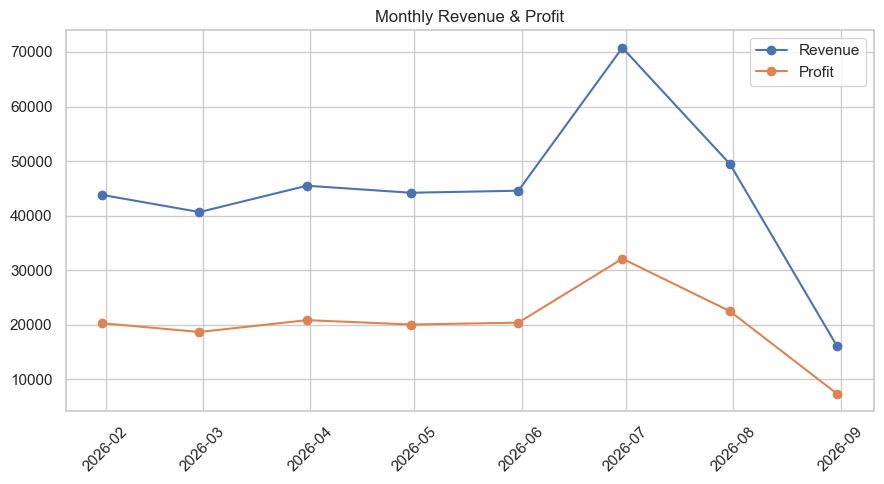

In [35]:
# Create a line chart comparing monthly revenue and profit.
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(monthly["Date"], monthly["Revenue"], marker="o", label="Revenue")
ax.plot(monthly["Date"], monthly["Profit"], marker="o", label="Profit")

# Add chart labels and a legend for interpretation.
ax.set_title("Monthly Revenue & Profit")
ax.legend()

# Improve date-label readability and finalize the layout.
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Q3 & Q4: Which products are driving sales and profitability?

"Driving sales" (volume/revenue) and "driving profitability" (profit/margin)
are different questions - a product can be high-volume but low-margin, or
vice versa, so I compute both side by side.


In [37]:
# Summarize units sold, revenue, and profit for each product.
by_product = (
    df.groupby("Product")
    .agg(Units_Sold=("Quantity", "sum"), Revenue=("Revenue", "sum"), Profit=("Profit", "sum"))
    .assign(Profit_Margin_Pct=lambda x: (x["Profit"] / x["Revenue"] * 100).round(2))
    .sort_values("Revenue", ascending=False)
)

# Display product performance ranked by revenue.
by_product


,Units_Sold,Revenue,Profit,Profit_Margin_Pct
Product,,,,
Canvas,496,63488,27776,43.75
Oxford,561,58905,26367,44.76
Brogues,523,58576,25104,42.86
Monk Straps,575,51175,24150,47.19
Boots,540,41040,19980,48.68
Slippers,342,40698,17784,43.70
Loafers,453,24462,11778,48.15
Derby,522,16704,9396,56.25


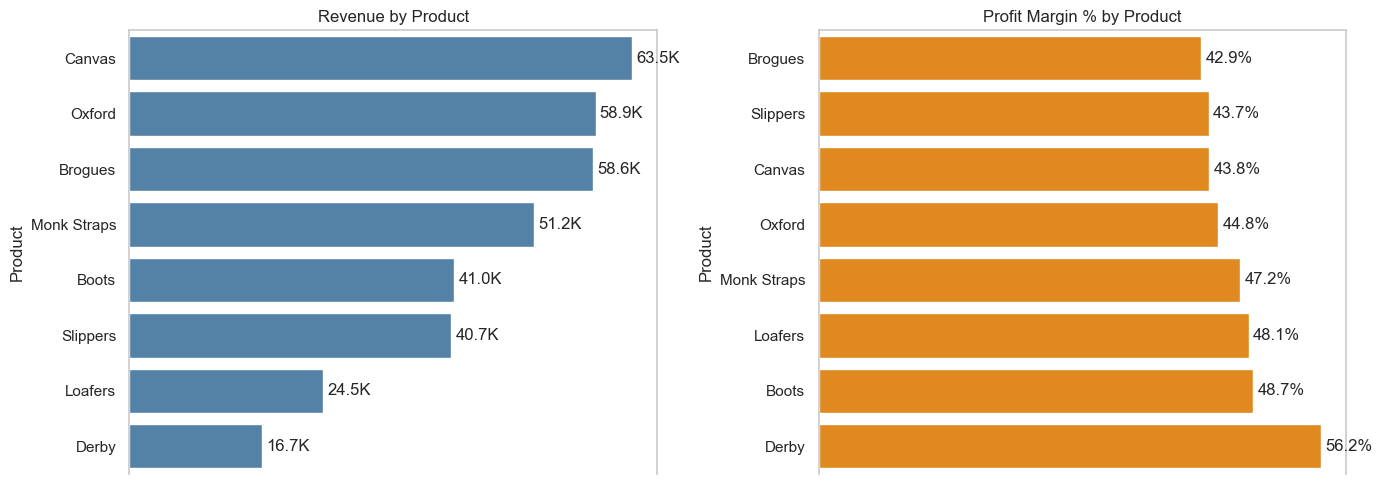

In [39]:
# Create side-by-side charts for product revenue and profit margin.
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor="white")

# Compare total revenue across products.
revenue_plot = sns.barplot(
    data=by_product.reset_index(),
    x="Revenue",
    y="Product",
    ax=axes[0],
    color="steelblue",
)
axes[0].set_title("Revenue by Product")
revenue_labels = [f"{value / 1000:.1f}K" for value in by_product["Revenue"]]
axes[0].bar_label(revenue_plot.containers[0], labels=revenue_labels, padding=3)

# Compare profit margins across products, ordered from lowest to highest.
margin_data = by_product.sort_values("Profit_Margin_Pct").reset_index()
margin_plot = sns.barplot(
    data=margin_data,
    x="Profit_Margin_Pct",
    y="Product",
    ax=axes[1],
    color="darkorange",
)
axes[1].set_title("Profit Margin % by Product")
margin_labels = [f"{value:.1f}%" for value in margin_data["Profit_Margin_Pct"]]
axes[1].bar_label(margin_plot.containers[0], labels=margin_labels, padding=3)

# Remove x-axis values, gridlines, and the bottom line below the bars.
for ax in axes:
    ax.set_facecolor("white")
    ax.set_xlabel("")
    ax.set_xticks([])
    ax.grid(False)
    ax.spines["bottom"].set_visible(False)

# Finalize spacing and display both charts.
plt.tight_layout()
plt.show()


## Q5: Which categories and brands perform best?

Grouping by **both** Category and Brand together
shows which specific combinations perform best - more actionable than
looking at either dimension in isolation.


In [40]:
# Summarize revenue and profit for each category and brand combination.
by_category_brand = (
    df.groupby(["Category", "Brand"])
    .agg(Revenue=("Revenue", "sum"), Profit=("Profit", "sum"))
    .sort_values("Revenue", ascending=False)
)

# Display the ten highest-revenue category and brand combinations.
by_category_brand.head(10)


Revenue  Profit
Category Brand                        
Formal   Clarks          64831   29555
         Zara            50985   23466
Casual   Clarks          27711   12821
Formal   Steve Madden    25352   11436
         Nike            25079   11426
Open     Clarks          21411    9764
Casual   Zara            19360    8727
         Nike            14680    6517
Formal   Timberland      13688    6391
Open     Zara            12607    5704

## Q6: Which countries contribute the most to the business?

`.rank()` gives each country an explicit revenue ranking alongside its
totals.


In [41]:
# Aggregate total revenue by country and rank countries by performance.
by_country = (
    df.groupby("Country")
    .agg(Revenue=("Revenue", "sum"))
    .sort_values("Revenue", ascending=False)
)

# Add an explicit revenue rank for each country.
by_country["Revenue_Rank"] = by_country["Revenue"].rank(ascending=False).astype(int)

# Display the country revenue ranking.
by_country


,Revenue,Revenue_Rank
Country,,
Usa,39127,1
Uk,32871,2
Ghana,32026,3
Zimbabwe,30124,4
India,29392,5
Kenya,26595,6
Cyprus,26531,7
Uganda,25851,8
Philippines,20810,9


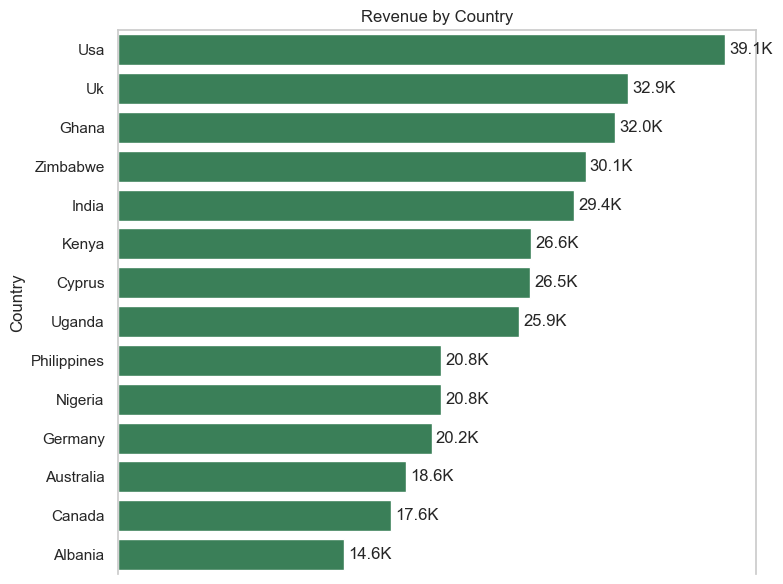

In [42]:
# Visualize total revenue contributed by each country.
fig, ax = plt.subplots(figsize=(8, 6), facecolor="white")
country_plot = sns.barplot(
    data=by_country.reset_index(),
    x="Revenue",
    y="Country",
    ax=ax,
    color="seagreen",
)

# Add revenue labels to the end of each bar using compact K formatting.
ax.set_title("Revenue by Country")
country_labels = [f"{value / 1000:.1f}K" for value in by_country["Revenue"]]
ax.bar_label(country_plot.containers[0], labels=country_labels, padding=3)

# Match the clean styling used in the product charts.
ax.set_facecolor("white")
ax.set_xlabel("")
ax.set_xticks([])
ax.grid(False)
ax.spines["bottom"].set_visible(False)

# Finalize the chart layout and display the result.
plt.tight_layout()
plt.show()


## Q7: What purchasing patterns exist by payment method and product preferences?

Grouping by `Payment Type` and `Category` together shows whether certain
payment methods skew toward certain kinds of purchases.


In [44]:
# Summarize units sold and revenue by payment method and product category.
by_payment_category = (
    df.groupby(["Payment Type", "Category"])
    .agg(Units_Sold=("Quantity", "sum"), Revenue=("Revenue", "sum"))
    .sort_values("Revenue", ascending=False)
)

# Display the ten highest-revenue payment and category combinations.
by_payment_category.head(10)


Units_Sold  Revenue
Payment Type  Category                     
Card          Formal           569    53656
Bank Transfer Formal           539    46622
Cash          Formal           481    42381
Mobile Money  Formal           436    37276
Cash          Casual           303    28029
Bank Transfer Casual           234    22849
Card          Open             194    18518
              Casual           232    17979
Mobile Money  Casual           166    14060
Bank Transfer Utility          161    13481

## Q8: What actions should management take based on the findings?

1. **Double down on the Formal category, especially Clarks and Zara** -
   consistently the top revenue and profit combination.
2. **Investigate Derby as an underused opportunity** - typically the
   highest profit margin of any product, but the lowest volume; more
   likely a visibility/marketing gap than weak demand.
3. **Confirm whether any sharp monthly drop is real or a partial month**
   in the data before treating it as a genuine trend.
4. **Review any consistently underperforming category** (e.g. "Open" or
   Utility) - decide whether it's a genuinely weak product line or
   under-marketed relative to Formal.
5. **Reallocate geographic focus toward top-performing countries**, and
   investigate the gap in the weakest ones (market size, distribution
   reach, or awareness) before deciding to invest more or pull back.
6. **Don't over-read the payment-method data** - if the breakdown looks
   fairly even across categories, avoid basing a strategic decision on
   payment mix alone (a separate ML analysis on this dataset might find
   payment type largely unpredictable from order attributes).


## Summary dashboard

A combined view of the key charts 


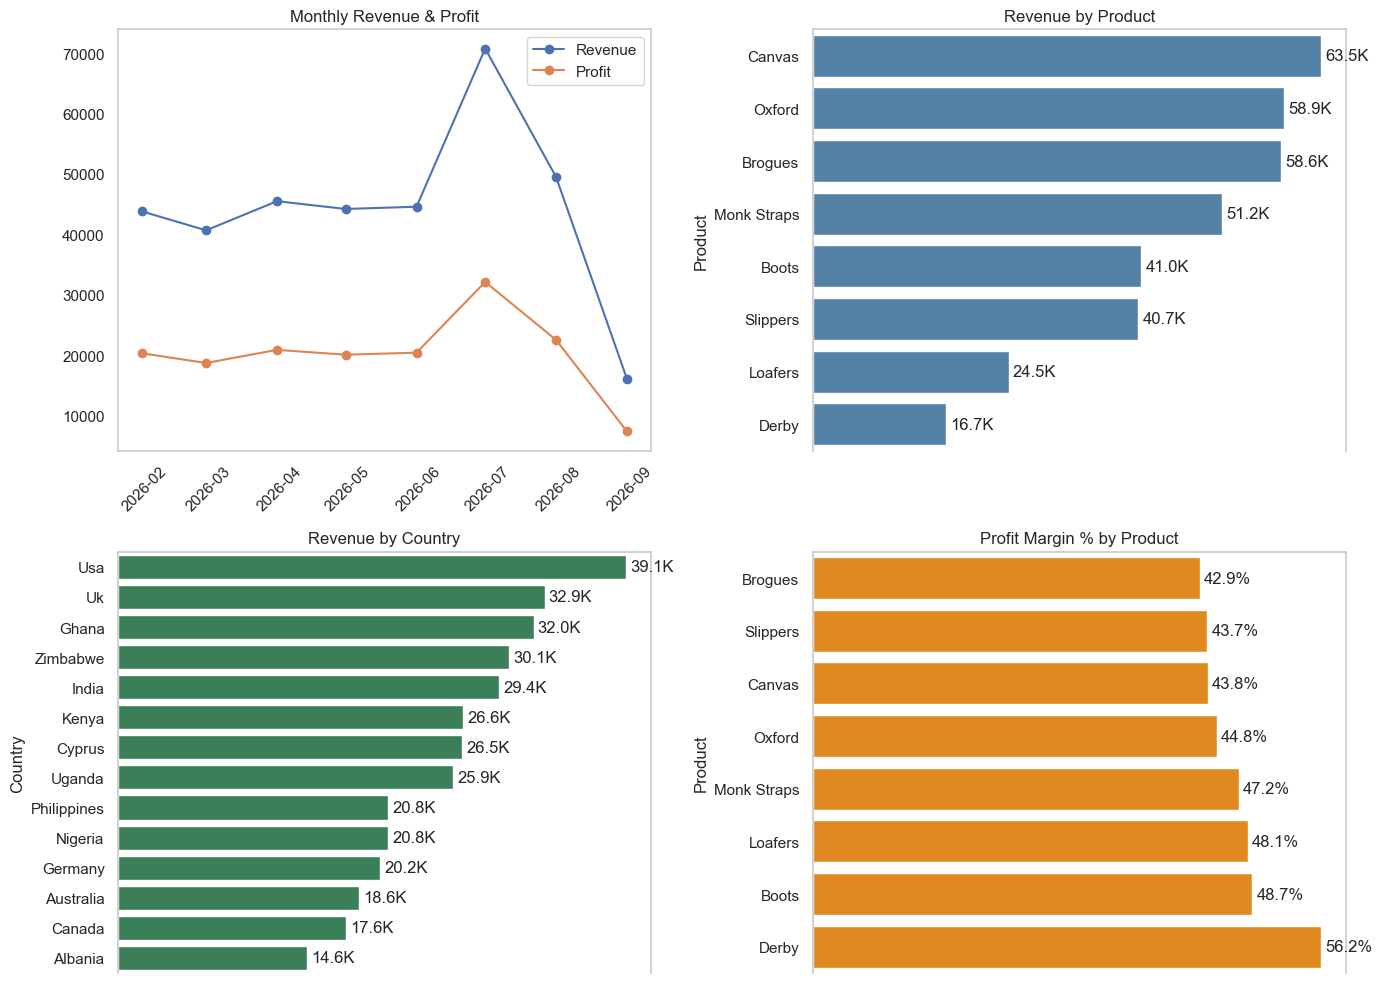

In [47]:
# Create a four-panel dashboard of the main business findings.
fig, axes = plt.subplots(2, 2, figsize=(14, 10), facecolor="white")

# Plot monthly revenue and profit trends.
axes[0, 0].plot(monthly["Date"], monthly["Revenue"], marker="o", label="Revenue")
axes[0, 0].plot(monthly["Date"], monthly["Profit"], marker="o", label="Profit")
axes[0, 0].set_title("Monthly Revenue & Profit")
axes[0, 0].legend()
axes[0, 0].tick_params(axis="x", rotation=45)
axes[0, 0].set_facecolor("white")
axes[0, 0].grid(False)

# Plot total revenue by product with compact value labels.
product_revenue_plot = sns.barplot(
    data=by_product.reset_index(),
    x="Revenue",
    y="Product",
    ax=axes[0, 1],
    color="steelblue",
)
axes[0, 1].set_title("Revenue by Product")
product_revenue_labels = [f"{value / 1000:.1f}K" for value in by_product["Revenue"]]
axes[0, 1].bar_label(product_revenue_plot.containers[0], labels=product_revenue_labels, padding=3)

# Plot total revenue by country with compact value labels.
country_revenue_plot = sns.barplot(
    data=by_country.reset_index(),
    x="Revenue",
    y="Country",
    ax=axes[1, 0],
    color="seagreen",
)
axes[1, 0].set_title("Revenue by Country")
country_revenue_labels = [f"{value / 1000:.1f}K" for value in by_country["Revenue"]]
axes[1, 0].bar_label(country_revenue_plot.containers[0], labels=country_revenue_labels, padding=3)

# Plot profit margin by product with percentage labels.
margin_data = by_product.sort_values("Profit_Margin_Pct").reset_index()
margin_plot = sns.barplot(
    data=margin_data,
    x="Profit_Margin_Pct",
    y="Product",
    ax=axes[1, 1],
    color="darkorange",
)
axes[1, 1].set_title("Profit Margin % by Product")
margin_labels = [f"{value:.1f}%" for value in margin_data["Profit_Margin_Pct"]]
axes[1, 1].bar_label(margin_plot.containers[0], labels=margin_labels, padding=3)

# Apply the clean chart styling used throughout the notebook.
for ax in axes.flat:
    ax.set_facecolor("white")
    ax.set_xlabel("")
    ax.grid(False)

for ax in axes.flat[1:]:
    ax.set_xticks([])
    ax.spines["bottom"].set_visible(False)

# Adjust spacing, save the dashboard, and display it.
plt.tight_layout()
plt.savefig("shoe_sales_dashboard.png", dpi=150, facecolor="white")
plt.show()
